In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from blended_learning.config.settings import settings

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score

import gower

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv(settings.path['output_cleaned_path'])

In [3]:
cluster_vars = list(settings.ordinal_column_scales.keys())
pretty_label = dict(settings.pretty_print_columns)

K_RANGE_GOWER = range(2, 7)
K_GOWER = 2

## 2. Gower Distance and Hierarchical Clustering

This section is an exploratory clustering check using Gower distance with hierarchical clustering. The main segmentation model remains K-Modes; this analysis is used to examine whether a distance-based clustering approach produces a similar student grouping pattern.

In [4]:
# ── Gower input preparation ─────────────────────────────────────────────────
X_gower = df[cluster_vars].copy()
X_gower = X_gower.apply(pd.to_numeric, errors='coerce')

print('Input shape:', X_gower.shape)
print('Total nulls :', X_gower.isna().sum().sum())

if X_gower.isna().sum().sum() > 0:
    X_gower = X_gower.fillna(X_gower.median(numeric_only=True))
    print('Missing values filled with column medians.')

# Gower is computed on the 33 encoded ordinal variables.
# Because all items use the same 1-5 scale, this preserves the ordered response structure.
X_gower = X_gower.astype(float)

Input shape: (420, 33)
Total nulls : 0


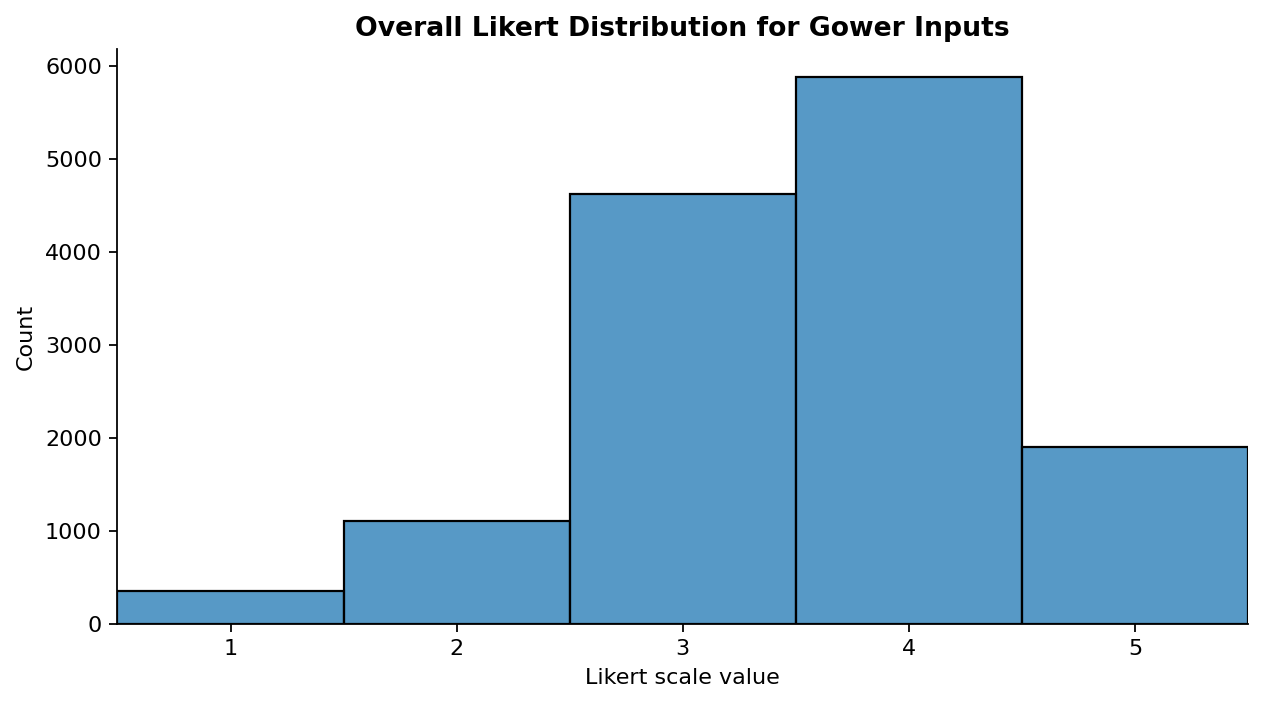

In [5]:
# ── Overall Likert distribution check ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=160)

sns.histplot(
    X_gower.values.flatten(),
    bins=np.arange(0.5, 6, 1),
    discrete=True,
    ax=ax
)

ax.set_title('Overall Likert Distribution for Gower Inputs', fontsize=12, weight='bold')
ax.set_xlabel('Likert scale value')
ax.set_ylabel('Count')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlim(0.5, 5.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
# ── Gower distance matrix and hierarchical linkage ──────────────────────────
D_gower = gower.gower_matrix(X_gower)
D_condensed = squareform(D_gower, checks=False)

Z_gower = linkage(D_condensed, method='average')

print('Gower distance matrix:', D_gower.shape)
print('Linkage matrix       :', Z_gower.shape)

Gower distance matrix: (420, 420)
Linkage matrix       : (419, 4)


In [7]:
# ── Gower hierarchical diagnostics search ───────────────────────────────────
gower_diag_results = []

for k in K_RANGE_GOWER:
    labels = fcluster(Z_gower, t=k, criterion='maxclust')
    counts = pd.Series(labels).value_counts().sort_index()

    silhouette = silhouette_score(D_gower, labels, metric='precomputed')
    largest_cluster_pct = counts.max() / counts.sum() * 100
    smallest_cluster_pct = counts.min() / counts.sum() * 100

    gower_diag_results.append({
        'k': k,
        'silhouette': silhouette,
        'largest_cluster_pct': largest_cluster_pct,
        'smallest_cluster_pct': smallest_cluster_pct,
        'cluster_sizes': counts.to_dict()
    })

gower_diag_df = pd.DataFrame(gower_diag_results)
display(gower_diag_df)

,k,silhouette,largest_cluster_pct,smallest_cluster_pct,cluster_sizes
0,2,0.465886,99.761905,0.238095,"{1: 419, 2: 1}"
1,3,0.393073,99.047619,0.238095,"{1: 3, 2: 416, 3: 1}"
2,4,0.343822,97.857143,0.238095,"{1: 3, 2: 5, 3: 411, 4: 1}"
3,5,0.313744,97.380952,0.238095,"{1: 3, 2: 5, 3: 2, 4: 409, 5: 1}"
4,6,0.309530,97.380952,0.238095,"{1: 2, 2: 1, 3: 5, 4: 2, 5: 409, 6: 1}"


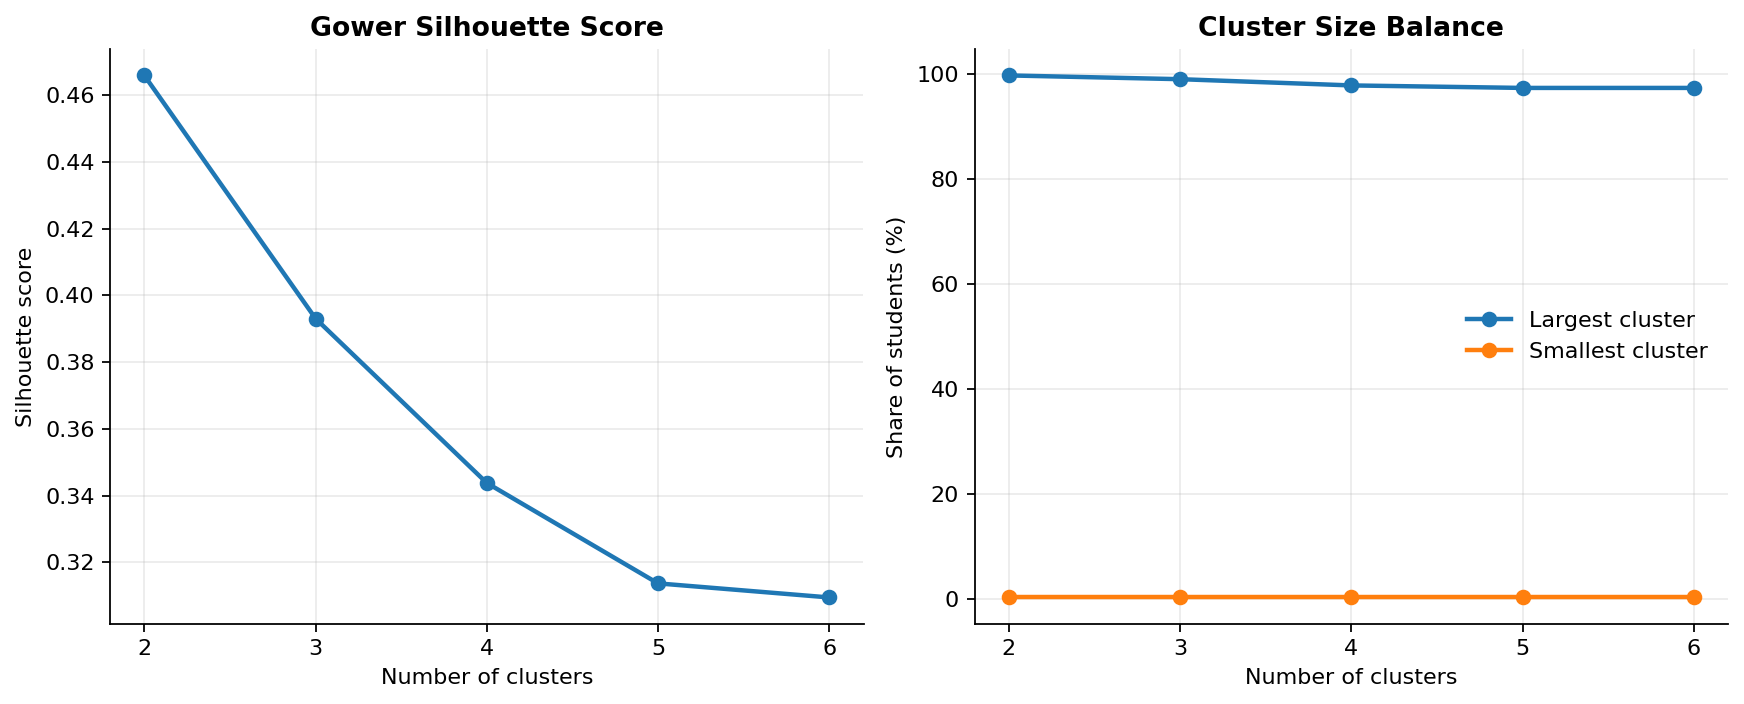

In [8]:
# ── Gower diagnostics figure ────────────────────────────────────────────────
k_vals = gower_diag_df['k'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=160)
fig.patch.set_facecolor('white')

def style_ax(ax):
    ax.set_xticks(k_vals)
    ax.grid(alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].plot(
    gower_diag_df['k'],
    gower_diag_df['silhouette'],
    marker='o',
    linewidth=2
)
axes[0].set_title('Gower Silhouette Score', fontsize=12, weight='bold')
axes[0].set_xlabel('Number of clusters')
axes[0].set_ylabel('Silhouette score')
style_ax(axes[0])

axes[1].plot(
    gower_diag_df['k'],
    gower_diag_df['largest_cluster_pct'],
    marker='o',
    linewidth=2,
    label='Largest cluster'
)
axes[1].plot(
    gower_diag_df['k'],
    gower_diag_df['smallest_cluster_pct'],
    marker='o',
    linewidth=2,
    label='Smallest cluster'
)
axes[1].set_title('Cluster Size Balance', fontsize=12, weight='bold')
axes[1].set_xlabel('Number of clusters')
axes[1].set_ylabel('Share of students (%)')
axes[1].legend(frameon=False)
style_ax(axes[1])

plt.tight_layout()
plt.show()

In [9]:
# ── Final Gower hierarchical cut ────────────────────────────────────────────
gower_labels = fcluster(Z_gower, t=K_GOWER, criterion='maxclust')

df['gower_cluster'] = gower_labels.astype(int)

print(f'Gower hierarchical clustering  K={K_GOWER}')
for cid in sorted(np.unique(gower_labels)):
    n = (gower_labels == cid).sum()
    print(f'  Cluster {cid}: {n} students ({n / len(gower_labels) * 100:.1f}%)')

Gower hierarchical clustering  K=2
  Cluster 1: 419 students (99.8%)
  Cluster 2: 1 students (0.2%)


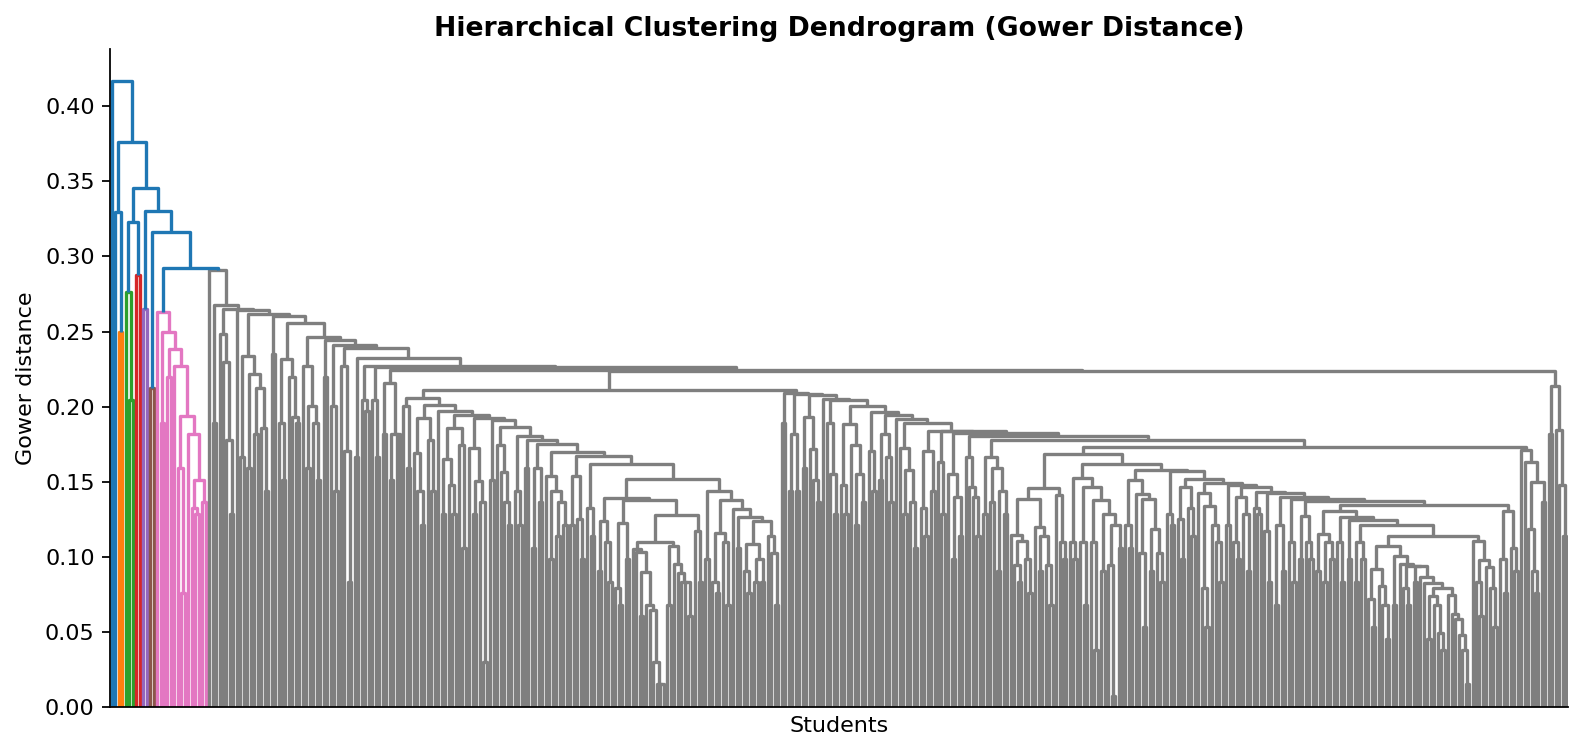

In [10]:
# ── Dendrogram for exploratory interpretation ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.8), dpi=160)

dendrogram(
    Z_gower,
    no_labels=True,
    color_threshold=None,
    ax=ax
)

ax.set_title('Hierarchical Clustering Dendrogram (Gower Distance)', fontsize=12, weight='bold')
ax.set_xlabel('Students')
ax.set_ylabel('Gower distance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 2.1 Gower Cluster Profile

In [11]:
# ── Profile Gower clusters on the 33 ordinal items ──────────────────────────
gower_profile_median = (
    df.groupby('gower_cluster')[cluster_vars]
    .median()
    .round(2)
)

display(gower_profile_median)

,use_lecture_slides,use_video_lectures,use_quizzes,use_articles,use_forums,use_simulations,online_discussion_participation,peer_collaboration,comfort_asking_questions,sense_of_community,...,digital_literacy_improvement,tech_issues_freq,lms_usability,overall_satisfaction,benefit_flexibility,benefit_variety,benefit_recorded_access,benefit_self_study_time,benefit_life_balance,benefit_self_directed
gower_cluster,,,,,,,,,,,,,,,,,,,,,
1,4.0,3.0,4.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,...,4.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
2,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,4.0,...,5.0,5.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,5.0


In [12]:
# ── Largest profile differences between Gower clusters ──────────────────────
if K_GOWER == 2:
    profile_diff = (
        gower_profile_median.loc[2] - gower_profile_median.loc[1]
    ).sort_values(key=lambda s: s.abs(), ascending=False)

    profile_diff_df = (
        profile_diff
        .rename('cluster_2_minus_cluster_1')
        .reset_index()
        .rename(columns={'index': 'variable'})
    )

    profile_diff_df['label'] = profile_diff_df['variable'].map(pretty_label).fillna(profile_diff_df['variable'])
    display(profile_diff_df.head(15))

,variable,cluster_2_minus_cluster_1,label
0,lect_responsive,-3.0,Lecturer Responsiveness
1,self_study_schedule,-3.0,Study Schedule
2,lect_diverse_tools,-3.0,Use of Diverse Tools
3,lect_timely_feedback,-3.0,Timely Feedback
4,lect_clear_instructions,-3.0,Clear Instructions
5,self_prioritize_deadlines,-3.0,Prioritising Deadlines
6,self_responsibility,-3.0,Learning Responsibility
7,lect_foster_interaction,-2.0,Encourages Interaction
8,use_video_lectures,2.0,Use of Video Lectures
9,self_prepare_class,-2.0,Preparation Before Class


### 2.2 Comparison with the Main K-Modes Segmentation

In [13]:
# ── Optional comparison with final K-Modes labels ───────────────────────────
# This comparison runs only when the main segmentation label already exists.
if 'student_segment' in df.columns:
    comparison_table = pd.crosstab(
        df['student_segment'].astype(int),
        df['gower_cluster'].astype(int),
        margins=True
    )

    nmi = normalized_mutual_info_score(df['student_segment'], df['gower_cluster'])
    ari = adjusted_rand_score(df['student_segment'], df['gower_cluster'])

    display(comparison_table)
    print(f'NMI: {nmi:.4f}')
    print(f'ARI: {ari:.4f}')
else:
    print('student_segment was not found. Run the K-Modes section first if you want a direct comparison.')

student_segment was not found. Run the K-Modes section first if you want a direct comparison.


### Gower note

Gower distance with hierarchical clustering is retained as an exploratory validation approach rather than the main segmentation model. K-Modes remains the primary model because the thesis segments are based on encoded ordinal/categorical Likert response patterns. Gower provides a useful distance-based comparison for checking whether broadly similar student groupings appear under an alternative clustering logic.